In [1]:
# ─── Block 1: Imports & Load Data ───────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

C:\Users\Navnith N Reddy\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Missing values: 0

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


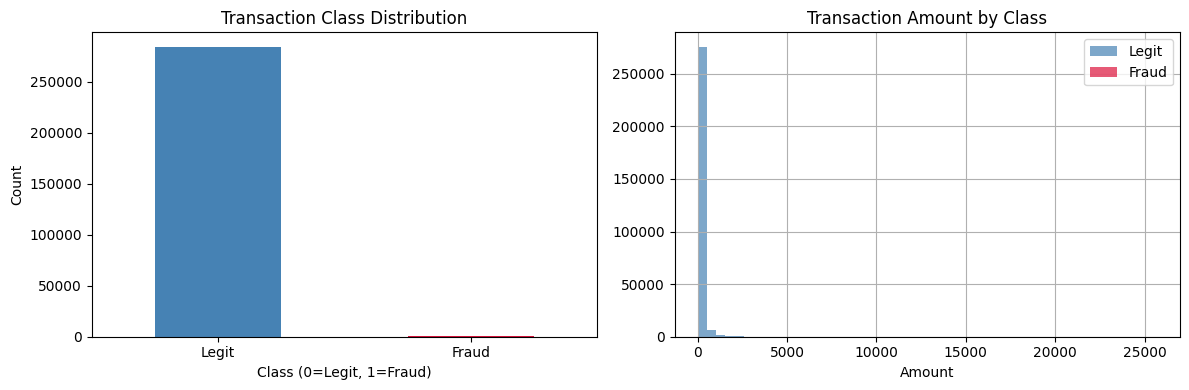

Plot saved!


In [3]:
# ─── Block 2: EDA + Class Imbalance ─────────────────────────────────────────

# Basic info
print("Missing values:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.4f}%")

# Plot class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'])
axes[0].set_title('Transaction Class Distribution')
axes[0].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legit', 'Fraud'], rotation=0)

# Amount distribution by class - fixed
for cls, color, label in zip([0, 1], ['steelblue', 'crimson'], ['Legit', 'Fraud']):
    df[df['Class'] == cls]['Amount'].hist(bins=50, ax=axes[1], 
                                          alpha=0.7, color=color, label=label)
axes[1].set_title('Transaction Amount by Class')
axes[1].set_xlabel('Amount')
axes[1].legend()

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150)
plt.show()
print("Plot saved!")

In [4]:
# ─── Block 3: Preprocessing + SMOTE ─────────────────────────────────────────

# Scale 'Amount' and 'Time' (V1-V28 are already PCA scaled)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time
df_clean = df.drop(['Amount', 'Time'], axis=1)

# Features and target
X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

# Train-test split (stratified so both splits have same fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print(f"  Training set size: {X_train.shape}")
print(f"  Fraud in train: {y_train.sum()} ({y_train.mean()*100:.2f}%)")

# Apply SMOTE to training set only (never on test set!)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Training set size: {X_train_sm.shape}")
print(f"  Fraud in train: {y_train_sm.sum()} ({y_train_sm.mean()*100:.2f}%)")

Before SMOTE:
  Training set size: (227845, 30)
  Fraud in train: 394 (0.17%)

After SMOTE:
  Training set size: (454902, 30)
  Fraud in train: 227451 (50.00%)


In [7]:
# ─── Block 4: Train Models ───────────────────────────────────────────────────

# Logistic Regression
print("Training Logistic Regression")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
print("Done")

# Random Forest
print("Training Random Forest")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
print("  Done")

# XGBoost
print("Training XGBoost")
xgb = XGBClassifier(n_estimators=100, random_state=42, 
                     eval_metric='logloss', verbosity=0)
xgb.fit(X_train_sm, y_train_sm)
print("  Done")

print("\nAll 3 models trained successfully")

Training Logistic Regression
Done
Training Random Forest
  Done
Training XGBoost
  Done

All 3 models trained successfully


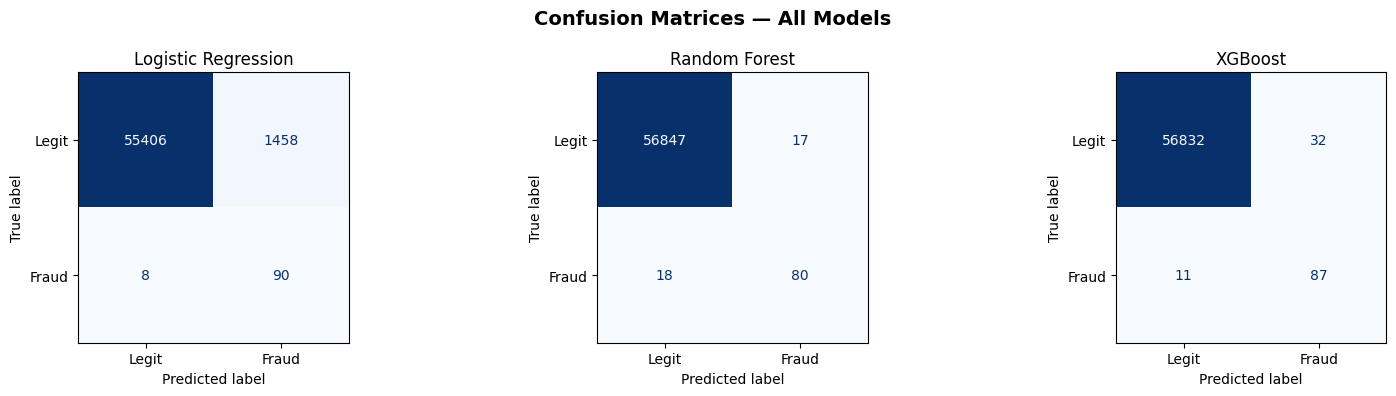

Saved!


In [8]:
# ─── Block 5: Confusion Matrices ─────────────────────────────────────────────

models = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Legit', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Saved!")

=== Model Comparison ===
              Model  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.0581  0.9184    0.1094   0.9698
      Random Forest     0.8247  0.8163    0.8205   0.9688
            XGBoost     0.7311  0.8878    0.8018   0.9792


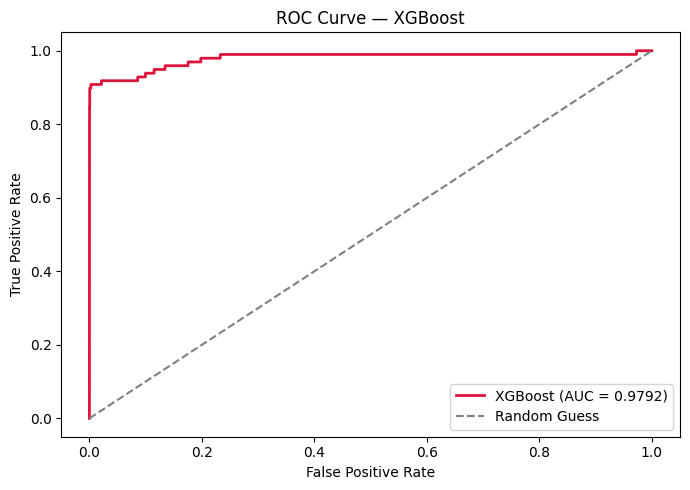

Saved!


In [9]:
# ─── Block 6: Model Comparison Table + ROC Curve ─────────────────────────────

from sklearn.metrics import precision_score, recall_score, f1_score

# Build comparison table
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results)
print("=== Model Comparison ===")
print(results_df.to_string(index=False))

# ROC Curve for best model (XGBoost)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
auc_score = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='crimson', lw=2, 
         label=f'XGBoost (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print("Saved!")

Generating SHAP values


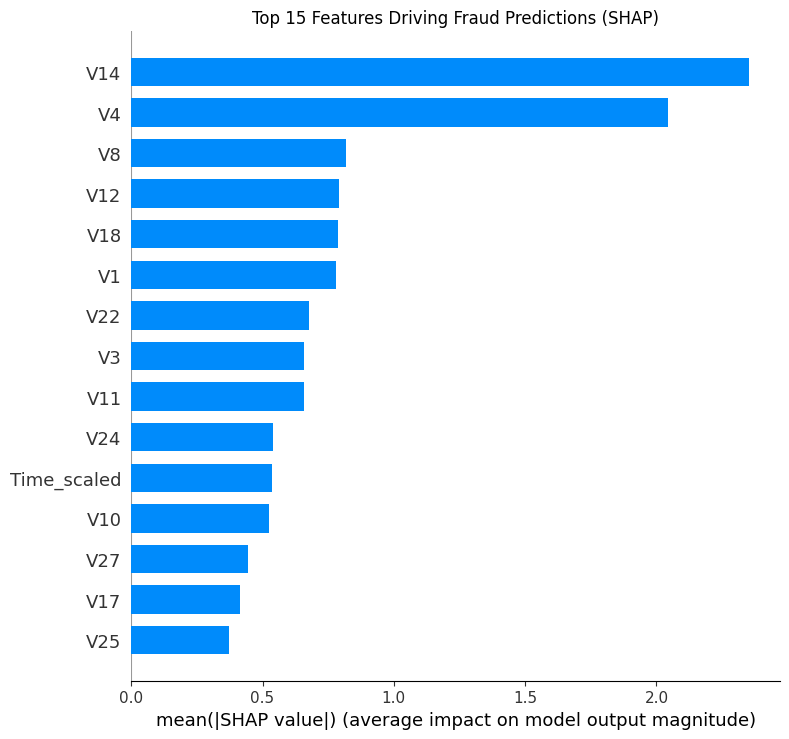

Saved!


In [10]:
# ─── Block 7: SHAP Explainability ────────────────────────────────────────────

print("Generating SHAP values")

# Use a sample of test data to speed it up
X_test_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sample)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", 
                  show=False, max_display=15)
plt.title("Top 15 Features Driving Fraud Predictions (SHAP)")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [12]:
# ─── Block 8: Findings & Conclusions ─────────────────────────────────────────

print("FINDINGS SUMMARY")
print("="*40)
print(f"Dataset: 284,807 transactions, only 0.17% fraud")
print(f"Main challenge: severe class imbalance, handled using SMOTE\n")

print("Model Performance:")
print(f"  Logistic Regression  — ROC-AUC: 0.9698, F1: 0.1094")
print(f"  Random Forest        — ROC-AUC: 0.9688, F1: 0.8205")
print(f"  XGBoost              — ROC-AUC: 0.9792, F1: 0.8018\n")

print("Conclusion:")
print("  XGBoost had the best overall discrimination (ROC-AUC 0.9792).")
print("  Random Forest had the best F1, meaning fewer false alarms.")
print("  Logistic Regression caught most fraud but flagged too many legit transactions.\n")

print("Key SHAP insight:")
print("  V14 and V4 were by far the strongest predictors of fraud.\n")



FINDINGS SUMMARY
Dataset: 284,807 transactions, only 0.17% fraud
Main challenge: severe class imbalance, handled using SMOTE

Model Performance:
  Logistic Regression  — ROC-AUC: 0.9698, F1: 0.1094
  Random Forest        — ROC-AUC: 0.9688, F1: 0.8205
  XGBoost              — ROC-AUC: 0.9792, F1: 0.8018

Conclusion:
  XGBoost had the best overall discrimination (ROC-AUC 0.9792).
  Random Forest had the best F1, meaning fewer false alarms.
  Logistic Regression caught most fraud but flagged too many legit transactions.

Key SHAP insight:
  V14 and V4 were by far the strongest predictors of fraud.

